## Methodology

### Training and Iterate Collection

A ResNet-20 (~272k parameters) is trained on 15,000 CIFAR-10 samples using SGD with constant learning rate ($\eta=0.1$, $\mu=0.9$, weight decay $10^{-4}$, batch size 128, 15 epochs, no learning-rate schedule). After every mini-batch update the full parameter vector $\theta_t \in \mathbb{R}^{272474}$ is stored in float32, yielding a trajectory matrix of shape $T \times D$ with $T = 1{,}770$ iterates.

### PCA of the Iterate Trajectory

Principal Component Analysis is applied to the centred iterate matrix. The explained variance ratio per component is compared against the theoretical spectrum predicted for an isotropic random walk by Antognini \& Sohl-Dickstein (2018):

$$\lambda_k^{\mathrm{RW}} \propto \frac{6}{\pi^2 k^2}$$

This $1/k^2$ decay is the null model: a trajectory with no directional structure should match it. Systematic deviation — in particular, a strongly dominant first component — indicates that the SGD trajectory is far more low-dimensional than expected from isotropic diffusion, reflecting a persistent drift component in the direction of steepest loss descent.

### Random Walk Baselines

Two random walk baselines are constructed with the same total path length as the SGD trajectory and the same starting point $\theta_0$: (i) an **isotropic random walk** with no drift, where each step is drawn uniformly from the unit hypersphere; and (ii) a **drifted random walk** with a constant drift component added in a fixed direction, mimicking the directional bias of gradient descent. PCA spectra, cumulative explained variance, and path efficiency (net displacement / total path length) are compared across all three trajectories to isolate which geometric properties are attributable to the gradient signal versus pure stochasticity.



In [1]:
# ============================================================
#  ZELLE 1 – Imports
# ============================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from torch.utils.data import DataLoader, Subset

In [2]:
# ============================================================
#  ZELLE 2 – Konfiguration
# ============================================================

TRAIN_SIZE   = 15000
TEST_SIZE    = 5000

LR           = 0.1
MOMENTUM     = 0.9
WEIGHT_DECAY = 1e-4    # L2
L1_LAMBDA    = 0.0     # L1 (0 = aus)

EPOCHS       = 15
BATCH_SIZE   = 128

# PCA-Komponenten für Trajektorien-Plot (1-basiert)
PC_X = 1
PC_Y = 2

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f'Device: {DEVICE}')
print(f'LR={LR} | Momentum={MOMENTUM} | WD={WEIGHT_DECAY} | L1={L1_LAMBDA}')
print(f'Epochen={EPOCHS} | Batch={BATCH_SIZE}')

Device: mps
LR=0.1 | Momentum=0.9 | WD=0.0001 | L1=0.0
Epochen=15 | Batch=128


In [3]:
# ============================================================
#  ZELLE 3 – ResNet20
# ============================================================

class BasicBlock(nn.Module):
    def __init__(self, in_planes, planes, stride=1):
        super().__init__()
        self.conv1    = nn.Conv2d(in_planes, planes, 3, stride=stride, padding=1, bias=False)
        self.bn1      = nn.BatchNorm2d(planes)
        self.conv2    = nn.Conv2d(planes, planes, 3, stride=1, padding=1, bias=False)
        self.bn2      = nn.BatchNorm2d(planes)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, planes, 1, stride=stride, bias=False),
                nn.BatchNorm2d(planes)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return F.relu(out)


class ResNet20(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1  = nn.Conv2d(3, 16, 3, padding=1, bias=False)
        self.bn1    = nn.BatchNorm2d(16)
        self.layer1 = self._make_layer(16, 16, 3, stride=1)
        self.layer2 = self._make_layer(16, 32, 3, stride=2)
        self.layer3 = self._make_layer(32, 64, 3, stride=2)
        self.linear = nn.Linear(64, num_classes)

    def _make_layer(self, in_planes, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers  = []
        for s in strides:
            layers.append(BasicBlock(in_planes, planes, s))
            in_planes = planes
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = F.avg_pool2d(out, out.size()[3])
        out = out.view(out.size(0), -1)
        return self.linear(out)


def get_param_vector(model):
    """Alle Parameter als flacher numpy-Vektor."""
    return torch.cat([
        p.data.flatten() for p in model.parameters()
    ]).cpu().numpy().astype(np.float32)


def get_grad_vector(model):
    """Alle Gradienten als flacher numpy-Vektor."""
    grads = []
    for p in model.parameters():
        if p.grad is not None:
            grads.append(p.grad.flatten())
        else:
            grads.append(torch.zeros_like(p.data).flatten())
    return torch.cat(grads).cpu().numpy().astype(np.float32)


D = sum(p.numel() for p in ResNet20().parameters())
print(f'ResNet20 bereit | Parameter: {D:,}')

ResNet20 bereit | Parameter: 272,474


In [4]:
# ============================================================
#  ZELLE 4 – Daten
# ============================================================

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])

full_train = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train)
full_test  = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test)

train_loader = DataLoader(Subset(full_train, range(TRAIN_SIZE)),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(Subset(full_test,  range(TEST_SIZE)),
                          batch_size=256,        shuffle=False, num_workers=2, pin_memory=True)

print(f'Train: {TRAIN_SIZE} | Test: {TEST_SIZE}')

Files already downloaded and verified
Files already downloaded and verified
Train: 15000 | Test: 5000


In [5]:
# ============================================================
#  ZELLE 5 – Training (kein LR-Schedule, jedes Iterate gespeichert)
# ============================================================

model     = ResNet20().to(DEVICE)
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=LR,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY
)
criterion = nn.CrossEntropyLoss()

history = {
    'train_acc':  [],
    'test_acc':   [],
    'train_loss': [],
    'test_loss':  [],
    'grad_norm_per_batch': [],   # jeder einzelne Batch
    'grad_norm_per_epoch': [],   # Mittelwert pro Epoche
}

# Iterates: jeder einzelne Batch-Update wird gespeichert
# RAM-Überlegung: T Batches * D Parameter * 4 Bytes
T_per_epoch = len(train_loader)
T_total     = T_per_epoch * EPOCHS
ram_mb      = T_total * D * 4 / 1e6
print(f'Batches pro Epoche: {T_per_epoch}')
print(f'Iterates total:     {T_total}')
print(f'Geschätzter RAM:    {ram_mb:.0f} MB')

iterates = []   # wird während Training befüllt
epoch_boundaries = []  # Batch-Index bei dem eine neue Epoche beginnt

batch_counter = 0

for epoch in range(1, EPOCHS + 1):
    epoch_boundaries.append(batch_counter)

    # ---------- TRAIN ----------
    model.train()
    correct, total, running_loss = 0, 0, 0.0
    epoch_grad_norms = []

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(DEVICE)
        batch_y = batch_y.to(DEVICE)

        optimizer.zero_grad()
        logits = model(batch_x)
        loss   = criterion(logits, batch_y)

        # L1
        if L1_LAMBDA > 0:
            l1 = sum(p.abs().sum() for p in model.parameters())
            loss = loss + L1_LAMBDA * l1

        loss.backward()

        # Gradientennorm VOR dem Step
        gnorm = np.linalg.norm(get_grad_vector(model))
        history['grad_norm_per_batch'].append(gnorm)
        epoch_grad_norms.append(gnorm)

        optimizer.step()

        # Iterate NACH dem Step speichern
        iterates.append(get_param_vector(model))

        batch_counter += 1

        running_loss += loss.item() * batch_x.size(0)
        correct      += (logits.argmax(1) == batch_y).sum().item()
        total        += batch_y.size(0)

    history['train_acc'].append(correct / total)
    history['train_loss'].append(running_loss / total)
    history['grad_norm_per_epoch'].append(np.mean(epoch_grad_norms))

    # ---------- TEST ----------
    model.eval()
    correct, total, running_loss = 0, 0, 0.0
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.to(DEVICE)
            batch_y = batch_y.to(DEVICE)
            logits  = model(batch_x)
            loss    = criterion(logits, batch_y)
            running_loss += loss.item() * batch_x.size(0)
            correct      += (logits.argmax(1) == batch_y).sum().item()
            total        += batch_y.size(0)

    history['test_acc'].append(correct / total)
    history['test_loss'].append(running_loss / total)

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoche {epoch:3d}/{EPOCHS} | '
              f'Train: {history["train_acc"][-1]:.3f} | '
              f'Test:  {history["test_acc"][-1]:.3f} | '
              f'Grad:  {history["grad_norm_per_epoch"][-1]:.4f}')

iterates         = np.array(iterates, dtype=np.float32)  # (T_total, D)
epoch_boundaries = np.array(epoch_boundaries)

print(f'\nFertig. iterates.shape = {iterates.shape}')
print(f'Tatsächlicher RAM:      {iterates.nbytes / 1e6:.0f} MB')

Batches pro Epoche: 118
Iterates total:     1770
Geschätzter RAM:    1929 MB
Epoche   1/15 | Train: 0.282 | Test:  0.332 | Grad:  1.4241
Epoche   5/15 | Train: 0.583 | Test:  0.566 | Grad:  0.9808
Epoche  10/15 | Train: 0.704 | Test:  0.674 | Grad:  0.9746
Epoche  15/15 | Train: 0.767 | Test:  0.724 | Grad:  0.9815

Fertig. iterates.shape = (1770, 272474)
Tatsächlicher RAM:      1929 MB


In [8]:
# ============================================================
#  ZELLE 8 – PCA auf alle Iterates
# ============================================================

N_COMPONENTS = 20

print(f'Berechne PCA auf {iterates.shape[0]} Iterates mit D={iterates.shape[1]}...')
pca = PCA(n_components=N_COMPONENTS)
Z   = pca.fit_transform(iterates)   # (T_total, N_COMPONENTS)

explained = pca.explained_variance_ratio_ * 100
cumulative = np.cumsum(explained)

print(f'PC{PC_X}: {explained[PC_X-1]:.2f}%')
print(f'PC{PC_Y}: {explained[PC_Y-1]:.2f}%')
print(f'Kumulativ PC1–{N_COMPONENTS}: {cumulative[-1]:.2f}%')

Berechne PCA auf 1770 Iterates mit D=272474...
PC1: 75.46%
PC2: 11.70%
Kumulativ PC1–20: 98.14%


In [21]:
# ============================================================
#  ZELLE 9 – Plot: Trajektorie im PC-Raum
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

EXPL = {1: 76.91, 2: 11.61}   # hardcoded explained variance (%)

def plot_trajectory(show_title=True):
    LBL, TTL, TCK = 16, 18, 14   # label / title / tick fontsize

    fig, ax = plt.subplots(figsize=(9, 7))

    # Färbung nach Batch-Index (= Zeit)
    time = np.arange(len(Z))
    sc   = ax.scatter(Z[:, PC_X-1], Z[:, PC_Y-1],
                      c=time, cmap='viridis', s=2, alpha=0.6, zorder=3)
    ax.plot(Z[:, PC_X-1], Z[:, PC_Y-1],
            color='gray', alpha=0.25, linewidth=0.9, zorder=2)

    # Epochengrenzen
    for eb in epoch_boundaries:
        ax.scatter(Z[eb, PC_X-1], Z[eb, PC_Y-1],
                   color='white', edgecolors='black',
                   s=30, zorder=4, linewidths=0.5)

    # Start / Ende
    ax.scatter(*Z[0,  [PC_X-1, PC_Y-1]], color='lime', s=120,
               zorder=6, label='Start', marker='o', edgecolors='black')
    ax.scatter(*Z[-1, [PC_X-1, PC_Y-1]], color='red', s=120,
               zorder=6, label='End', marker='X', edgecolors='black')

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Batch iteration', fontsize=LBL)
    cbar.ax.tick_params(labelsize=TCK)

    ax.set_xlabel(f'PC{PC_X}  ({EXPL[PC_X]:.2f}%)', fontsize=LBL)
    ax.set_ylabel(f'PC{PC_Y}  ({EXPL[PC_Y]:.2f}%)', fontsize=LBL)
    ax.tick_params(axis='both', labelsize=TCK)

    if show_title:
        ax.set_title(f'SGD trajectory in PC{PC_X}/PC{PC_Y} space\n'
                     f'White dots = epoch boundaries', fontsize=TTL)

    ax.legend(loc='upper left', fontsize=TCK)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

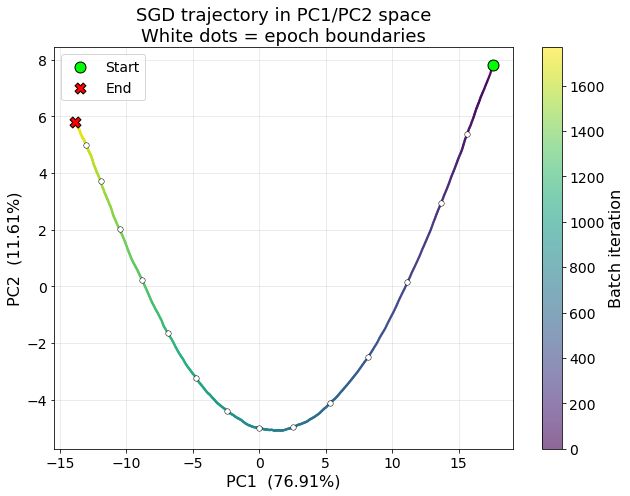

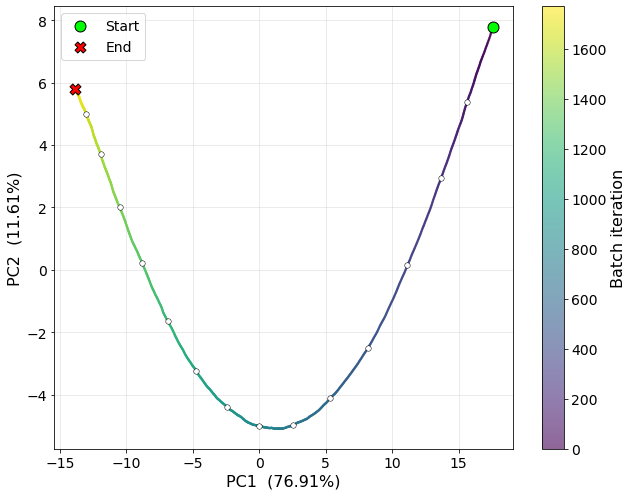

In [22]:
plot_trajectory(show_title=True)
plot_trajectory(show_title=False)

In [29]:
# ============================================================
#  ZELLE 9 – PC-Trajektorien
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

LBL, TTL, TCK = 17, 19, 15   # label / title / tick fontsize

EXPL = {1: 76.91, 2: 11.61}          # hardcoded explained variance (%)
def expl(pc):                        # Fallback auf berechnete Werte
    return EXPL.get(pc, explained[pc-1])


def plot_pc_pair(pc_x=1, pc_y=2, show_title=True):
    fig, ax = plt.subplots(figsize=(9, 7))

    time = np.arange(len(Z))
    sc = ax.scatter(Z[:, pc_x-1], Z[:, pc_y-1],
                    c=time, cmap='viridis', s=2, alpha=0.6, zorder=3)
    ax.plot(Z[:, pc_x-1], Z[:, pc_y-1],
            color='gray', alpha=0.35, linewidth=1.4, zorder=2)

    for eb in epoch_boundaries:
        ax.scatter(Z[eb, pc_x-1], Z[eb, pc_y-1],
                   color='white', edgecolors='black',
                   s=30, zorder=4, linewidths=0.8)

    ax.scatter(*Z[0,  [pc_x-1, pc_y-1]], color='lime', s=120,
               zorder=6, label='Start', marker='o', edgecolors='black')
    ax.scatter(*Z[-1, [pc_x-1, pc_y-1]], color='red', s=120,
               zorder=6, label='End', marker='X', edgecolors='black')

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Batch iteration', fontsize=LBL)
    cbar.ax.tick_params(labelsize=TCK)

    ax.set_xlabel(f'PC{pc_x}  ({expl(pc_x):.2f}%)', fontsize=LBL)
    ax.set_ylabel(f'PC{pc_y}  ({expl(pc_y):.2f}%)', fontsize=LBL)
    ax.tick_params(axis='both', labelsize=TCK)

    if show_title:
        ax.set_title(f'SGD trajectory in PC{pc_x}/PC{pc_y} space\n'
                     f'White dots = epoch boundaries', fontsize=TTL)

    ax.legend(loc='upper left', fontsize=TCK)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [32]:
def plot_pc_timeseries(pcs=(1, 2, 3), show_title=True):
    fig, ax = plt.subplots(figsize=(12, 6))

    time   = np.arange(len(Z))
    colors = ['steelblue', 'seagreen', 'tomato']

    for pc, c in zip(pcs, colors):
        ax.plot(time, Z[:, pc-1], color=c, lw=2.4,
                label=f'PC{pc}  ({expl(pc):.2f}%)')

    for eb in epoch_boundaries:
        ax.axvline(eb, color='gray', alpha=0.3, lw=1.2, zorder=1)

    ax.set_xlabel('Batch iteration', fontsize=LBL)
    ax.set_ylabel('Projection', fontsize=LBL)
    ax.tick_params(axis='both', labelsize=TCK)

    if show_title:
        ax.set_title('PC projections over training\n'
                     , fontsize=TTL)

    ax.legend(loc='best', fontsize=TCK)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

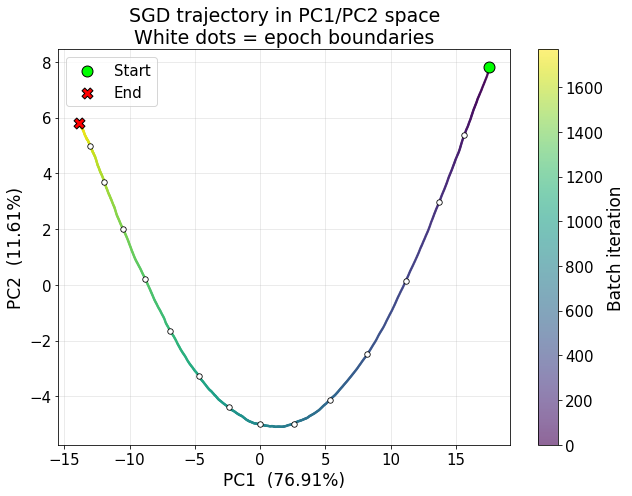

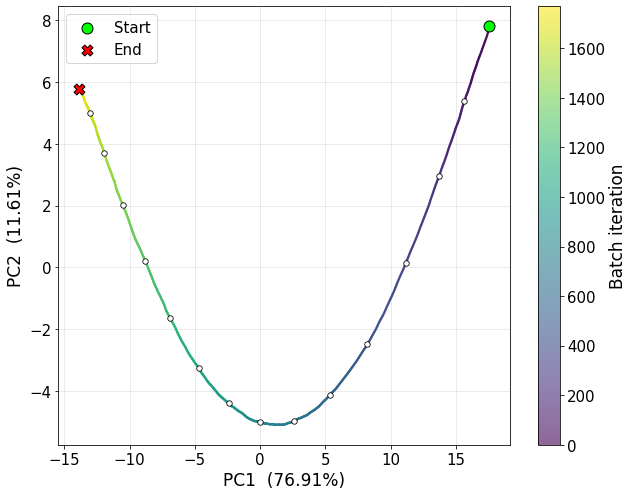

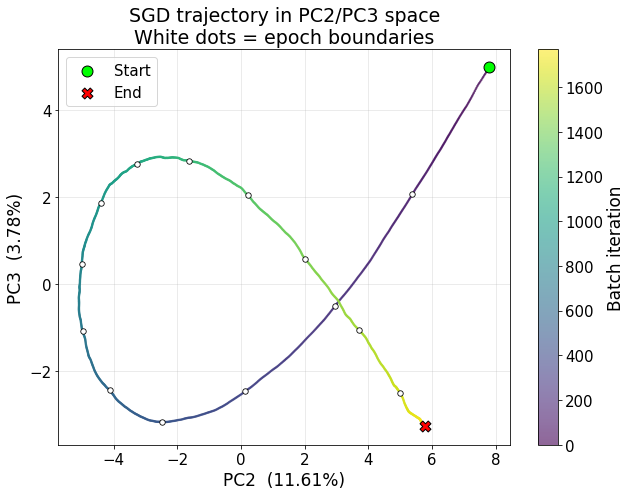

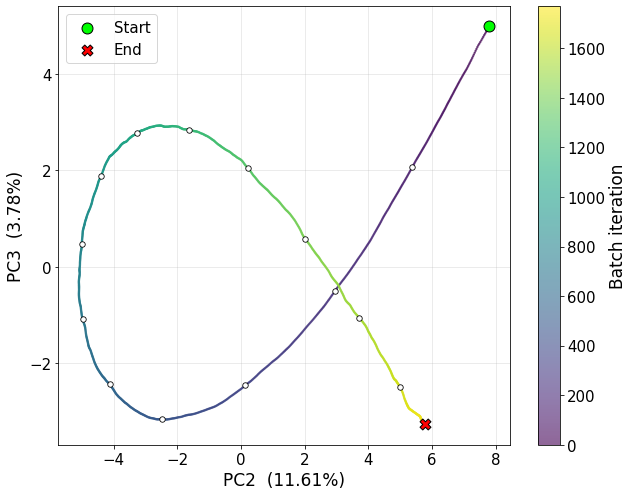

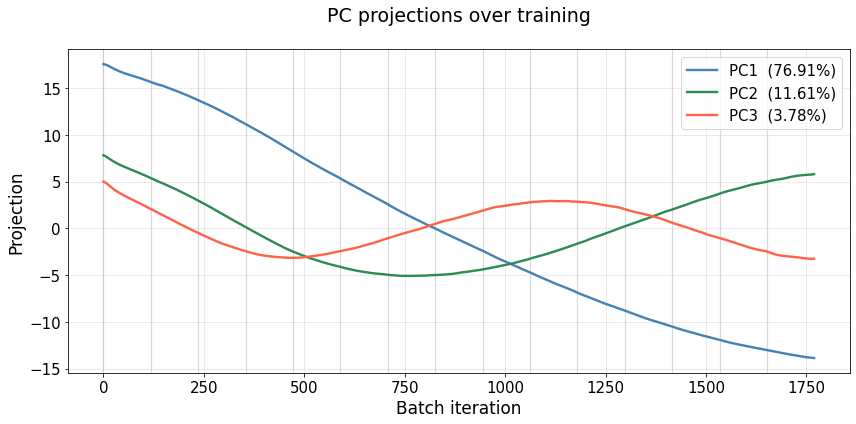

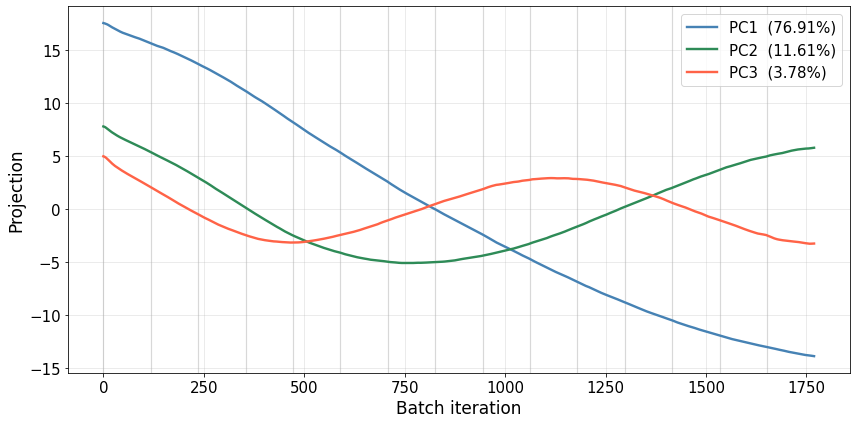

In [33]:
plot_pc_pair(1, 2, show_title=True)
plot_pc_pair(1, 2, show_title=False)

plot_pc_pair(2, 3, show_title=True)
plot_pc_pair(2, 3, show_title=False)

plot_pc_timeseries(show_title=True)
plot_pc_timeseries(show_title=False)

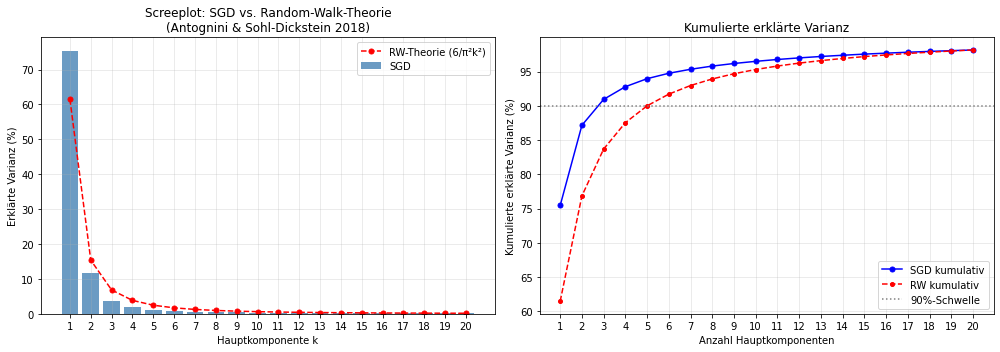


  PC | Varianz (%) | Kumulativ (%) | RW-Theorie (%)
--------------------------------------------------
PC 1 |       75.46 |         75.46 |          61.49
PC 2 |       11.70 |         87.16 |          15.37
PC 3 |        3.78 |         90.94 |           6.83
PC 4 |        1.85 |         92.78 |           3.84
PC 5 |        1.17 |         93.95 |           2.46
PC 6 |        0.79 |         94.75 |           1.71
PC 7 |        0.58 |         95.33 |           1.25
PC 8 |        0.47 |         95.79 |           0.96
PC 9 |        0.38 |         96.17 |           0.76
PC10 |        0.31 |         96.49 |           0.61
PC11 |        0.27 |         96.76 |           0.51
PC12 |        0.23 |         96.99 |           0.43
PC13 |        0.21 |         97.19 |           0.36
PC14 |        0.18 |         97.37 |           0.31
PC15 |        0.17 |         97.54 |           0.27
PC16 |        0.14 |         97.68 |           0.24
PC17 |        0.13 |         97.81 |           0.21
PC18 |      

In [34]:
# ============================================================
#  ZELLE 10 – Screeplot
# ============================================================

k         = np.arange(1, N_COMPONENTS + 1)
rw_theory = 6 / (np.pi**2 * k**2)
rw_theory = rw_theory / rw_theory.sum() * explained.sum()  # gleiche Gesamtsumme

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Erklärte Varianz
ax = axes[0]
ax.bar(k, explained, color='steelblue', alpha=0.8, label='SGD')
ax.plot(k, rw_theory, 'r--o', markersize=5,
        linewidth=1.5, label='RW-Theorie (6/π²k²)')
ax.set_xlabel('Hauptkomponente k')
ax.set_ylabel('Erklärte Varianz (%)')
ax.set_title('Screeplot: SGD vs. Random-Walk-Theorie\n(Antognini & Sohl-Dickstein 2018)')
ax.legend(); ax.grid(alpha=0.3); ax.set_xticks(k)

# Kumulierte Varianz
ax = axes[1]
ax.plot(k, cumulative,              'b-o', markersize=5, label='SGD kumulativ')
ax.plot(k, np.cumsum(rw_theory),    'r--o', markersize=4, label='RW kumulativ')
ax.axhline(90, color='gray', linestyle=':', linewidth=1.5, label='90%-Schwelle')
ax.set_xlabel('Anzahl Hauptkomponenten')
ax.set_ylabel('Kumulierte erklärte Varianz (%)')
ax.set_title('Kumulierte erklärte Varianz')
ax.legend(); ax.grid(alpha=0.3); ax.set_xticks(k)

plt.tight_layout()
plt.show()

print(f'\n{"PC":>4} | {"Varianz (%)":>11} | {"Kumulativ (%)":>13} | {"RW-Theorie (%)":>14}')
print('-' * 50)
for i in range(N_COMPONENTS):
    print(f'PC{i+1:2d} | {explained[i]:>11.2f} | {cumulative[i]:>13.2f} | {rw_theory[i]:>14.2f}')

In [39]:
# ============================================================
#  ZELLE 10 – Screeplot
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

LBL, TTL, TCK = 16, 17, 13   # label / title / tick fontsize

def plot_scree(show_title=True):
    k         = np.arange(1, N_COMPONENTS + 1)
    rw_theory = 6 / (np.pi**2 * k**2)
    rw_theory = rw_theory / rw_theory.sum() * explained.sum()   # gleiche Gesamtsumme

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

    # --- Explained variance ---
    ax = axes[0]
    ax.bar(k, explained, color='steelblue', alpha=0.8, label='SGD')
    ax.plot(k, rw_theory, 'r--o', markersize=6, linewidth=2.2,
            label='Random walk')
    ax.set_xlabel('Principal component k', fontsize=LBL)
    ax.set_ylabel('Explained variance (%)', fontsize=LBL)
    if show_title:
        ax.set_title('Scree plot: SGD vs. random walk', fontsize=TTL)

    # --- Cumulative variance ---
    ax = axes[1]
    ax.plot(k, cumulative, 'b-o', markersize=6, linewidth=2.2,
            label='SGD cumulative')
    ax.plot(k, np.cumsum(rw_theory), 'r--o', markersize=5, linewidth=2.2,
            label='Random walk cumulative')
    ax.axhline(90, color='gray', linestyle=':', linewidth=2.0,
               label='90% threshold')
    ax.set_xlabel('Number of principal components', fontsize=LBL)
    ax.set_ylabel('Cumulative explained variance (%)', fontsize=LBL)
    if show_title:
        ax.set_title('Cumulative explained variance', fontsize=TTL)

    for ax in axes:
        ax.legend(fontsize=TCK)
        ax.grid(alpha=0.3)
        ax.set_xticks(k)
        ax.tick_params(axis='both', labelsize=TCK)

    plt.tight_layout()
    plt.show()

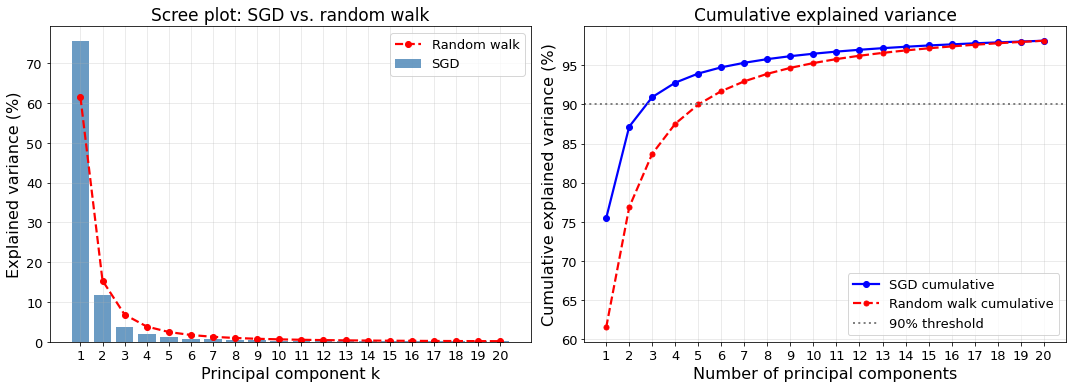

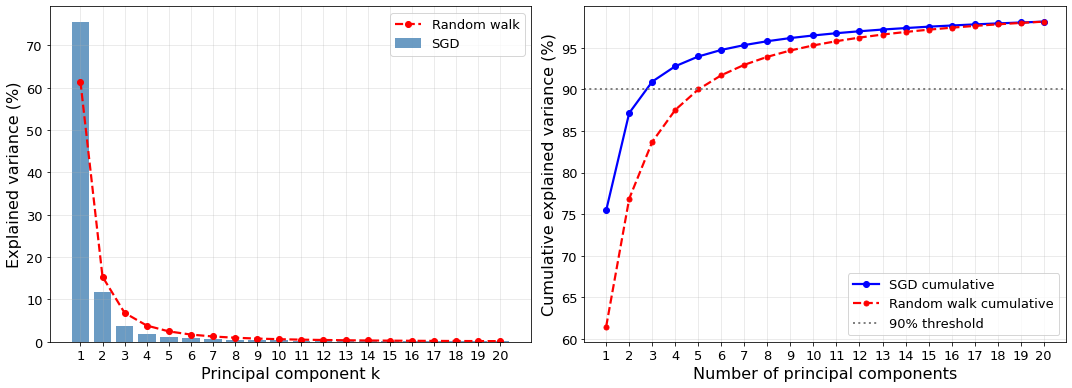


  PC | Variance (%) | Cumulative (%) | Random walk (%)
-------------------------------------------------------
PC 1 |        75.46 |          75.46 |           61.49
PC 2 |        11.70 |          87.16 |           15.37
PC 3 |         3.78 |          90.94 |            6.83
PC 4 |         1.85 |          92.78 |            3.84
PC 5 |         1.17 |          93.95 |            2.46
PC 6 |         0.79 |          94.75 |            1.71
PC 7 |         0.58 |          95.33 |            1.25
PC 8 |         0.47 |          95.79 |            0.96
PC 9 |         0.38 |          96.17 |            0.76
PC10 |         0.31 |          96.49 |            0.61
PC11 |         0.27 |          96.76 |            0.51
PC12 |         0.23 |          96.99 |            0.43
PC13 |         0.21 |          97.19 |            0.36
PC14 |         0.18 |          97.37 |            0.31
PC15 |         0.17 |          97.54 |            0.27
PC16 |         0.14 |          97.68 |            0.24
PC17 |  

In [40]:
plot_scree(show_title=True)
plot_scree(show_title=False)

k         = np.arange(1, N_COMPONENTS + 1)
rw_theory = 6 / (np.pi**2 * k**2)
rw_theory = rw_theory / rw_theory.sum() * explained.sum()

print(f'\n{"PC":>4} | {"Variance (%)":>12} | {"Cumulative (%)":>14} | {"Random walk (%)":>15}')
print('-' * 55)
for i in range(N_COMPONENTS):
    print(f'PC{i+1:2d} | {explained[i]:>12.2f} | {cumulative[i]:>14.2f} | {rw_theory[i]:>15.2f}')

### Random Walk

In [11]:
# ============================================================
#  ZELLE RW1 – Konfiguration Random Walk
# ============================================================

# Schrittweite aus SGD-Statistik:
# σ so dass E[||Schritt||] = mittlere SGD-Schrittweite
sgd_step_norms = np.linalg.norm(np.diff(iterates, axis=0), axis=1)
STEP_SIZE      = sgd_step_norms.mean()

T_RW  = len(iterates)   # gleiche Länge wie SGD-Trajektorie
D_RW  = iterates.shape[1]  # gleicher Parameterraum

# Drift-Richtung: mittlere Nettobewegung pro Schritt von SGD
sgd_steps     = np.diff(iterates, axis=0)           # (T-1, D)
drift_vector  = sgd_steps.mean(axis=0)              # (D,)  mittlerer Schritt
drift_norm    = np.linalg.norm(drift_vector)

# Skaliere Drift so dass ||drift|| / ||Rauschen|| ≈ SGD-Verhältnis
sigma = STEP_SIZE / np.sqrt(D_RW)

print(f'Parameterraum D:        {D_RW:,}')
print(f'Trajektorienlänge T:    {T_RW}')
print(f'Mittlere SGD-Schrittw.: {STEP_SIZE:.6f}')
print(f'σ pro Dimension:        {sigma:.8f}')
print(f'Drift-Norm (SGD):       {drift_norm:.6f}')

Parameterraum D:        272,474
Trajektorienlänge T:    1770
Mittlere SGD-Schrittw.: 0.207621
σ pro Dimension:        0.00039775
Drift-Norm (SGD):       0.019172


In [12]:
# ============================================================
#  ZELLE RW2 – Random Walk OHNE Drift
# ============================================================

rng = np.random.default_rng(42)

rw_no_drift    = np.zeros((T_RW, D_RW), dtype=np.float32)
theta_rw       = np.zeros(D_RW, dtype=np.float32)

# Startpunkt = gleicher Startpunkt wie SGD
theta_rw = iterates[0].copy()

for t in range(T_RW):
    step         = rng.standard_normal(D_RW).astype(np.float32) * sigma
    theta_rw     = theta_rw + step
    rw_no_drift[t] = theta_rw

# Schrittweiten prüfen
steps_nd   = np.diff(rw_no_drift, axis=0)
norms_nd   = np.linalg.norm(steps_nd, axis=1)

print(f'RW ohne Drift – Shape: {rw_no_drift.shape}')
print(f'Mittlere Schrittweite: {norms_nd.mean():.6f}  (SGD: {STEP_SIZE:.6f})')
print(f'Std Schrittweite:      {norms_nd.std():.6f}')

RW ohne Drift – Shape: (1770, 272474)
Mittlere Schrittweite: 0.207618  (SGD: 0.207621)
Std Schrittweite:      0.000281


In [13]:
# ============================================================
#  ZELLE RW3 – Random Walk MIT Drift
# ============================================================

rng2 = np.random.default_rng(99)

rw_drift   = np.zeros((T_RW, D_RW), dtype=np.float32)
theta_rwd  = iterates[0].copy()

# Drift = mittlerer SGD-Schritt, normiert auf anteilige Schrittweite
# Wir wollen: ||drift|| + ||rauschen|| ≈ STEP_SIZE
# Drift-Anteil: 50% der Schrittweite in mittlerer SGD-Richtung
drift_fraction = 0.5
drift_step     = (drift_vector / (drift_norm + 1e-10)) * STEP_SIZE * drift_fraction
noise_sigma    = np.sqrt(max((STEP_SIZE**2 - np.linalg.norm(drift_step)**2) / D_RW, 1e-12))

for t in range(T_RW):
    noise       = rng2.standard_normal(D_RW).astype(np.float32) * noise_sigma
    theta_rwd   = theta_rwd + drift_step + noise
    rw_drift[t] = theta_rwd

steps_wd  = np.diff(rw_drift, axis=0)
norms_wd  = np.linalg.norm(steps_wd, axis=1)

print(f'RW mit Drift – Shape: {rw_drift.shape}')
print(f'Drift-Norm pro Schritt:  {np.linalg.norm(drift_step):.6f}')
print(f'Mittlere Schrittweite:   {norms_wd.mean():.6f}  (SGD: {STEP_SIZE:.6f})')
print(f'Std Schrittweite:        {norms_wd.std():.6f}')

RW mit Drift – Shape: (1770, 272474)
Drift-Norm pro Schritt:  0.103811
Mittlere Schrittweite:   0.207616  (SGD: 0.207621)
Std Schrittweite:        0.000273


In [14]:
# ============================================================
#  ZELLE RW4 – PCA für beide Random Walks
# ============================================================

N_COMPONENTS_RW = 20

print('Berechne PCA für RW ohne Drift...')
pca_nd  = PCA(n_components=N_COMPONENTS_RW)
Z_nd    = pca_nd.fit_transform(rw_no_drift)
exp_nd  = pca_nd.explained_variance_ratio_ * 100
cum_nd  = np.cumsum(exp_nd)

print('Berechne PCA für RW mit Drift...')
pca_wd  = PCA(n_components=N_COMPONENTS_RW)
Z_wd    = pca_wd.fit_transform(rw_drift)
exp_wd  = pca_wd.explained_variance_ratio_ * 100
cum_wd  = np.cumsum(exp_wd)

print(f'\nRW ohne Drift – PC{PC_X}: {exp_nd[PC_X-1]:.2f}%  |  PC{PC_Y}: {exp_nd[PC_Y-1]:.2f}%')
print(f'RW mit Drift  – PC{PC_X}: {exp_wd[PC_X-1]:.2f}%  |  PC{PC_Y}: {exp_wd[PC_Y-1]:.2f}%')

Berechne PCA für RW ohne Drift...
Berechne PCA für RW mit Drift...

RW ohne Drift – PC1: 60.85%  |  PC2: 15.16%
RW mit Drift  – PC1: 99.86%  |  PC2: 0.05%


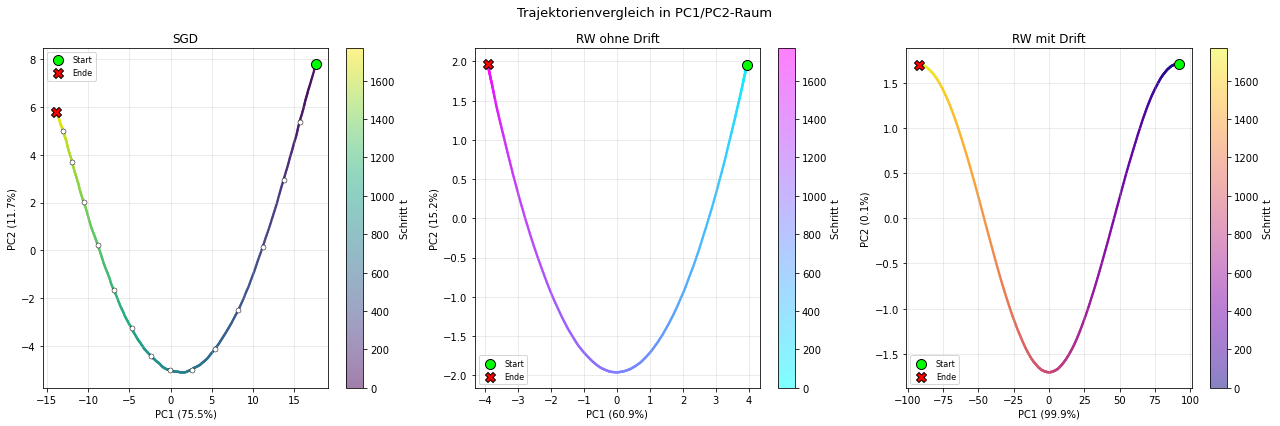

In [15]:
# ============================================================
#  ZELLE RW8 – Direkter Vergleich alle drei Trajektorien
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

datasets = [
    (Z,    explained, 'viridis',  'SGD',             epoch_boundaries),
    (Z_nd, exp_nd,    'cool',     'RW ohne Drift',   None),
    (Z_wd, exp_wd,    'plasma',   'RW mit Drift',    None),
]

for ax, (Z_plot, exp_plot, cmap, title, boundaries) in zip(axes, datasets):
    time_plot = np.arange(len(Z_plot))
    sc = ax.scatter(Z_plot[:, PC_X-1], Z_plot[:, PC_Y-1],
                    c=time_plot, cmap=cmap, s=2, alpha=0.5)
    ax.plot(Z_plot[:, PC_X-1], Z_plot[:, PC_Y-1],
            color='gray', alpha=0.1, linewidth=0.4)
    ax.scatter(*Z_plot[0,  [PC_X-1, PC_Y-1]], color='lime', s=100,
               zorder=5, marker='o', edgecolors='black', label='Start')
    ax.scatter(*Z_plot[-1, [PC_X-1, PC_Y-1]], color='red',  s=100,
               zorder=5, marker='X', edgecolors='black', label='Ende')
    if boundaries is not None:
        for eb in boundaries:
            ax.scatter(Z_plot[eb, PC_X-1], Z_plot[eb, PC_Y-1],
                       color='white', edgecolors='black',
                       s=25, zorder=4, linewidths=0.5)
    plt.colorbar(sc, ax=ax, label='Schritt t')
    ax.set_xlabel(f'PC{PC_X} ({exp_plot[PC_X-1]:.1f}%)')
    ax.set_ylabel(f'PC{PC_Y} ({exp_plot[PC_Y-1]:.1f}%)')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle(f'Trajektorienvergleich in PC{PC_X}/PC{PC_Y}-Raum',
             fontsize=13)
plt.tight_layout()
plt.show()

In [45]:
# ============================================================
#  ZELLE RW8 – Trajektorie Random Walk ohne Drift
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

LBL, TTL, TCK = 16, 18, 14  # label / title / tick fontsize

def plot_rw_nodrift(pc_x=1, pc_y=2, show_title=True):
    fig, ax = plt.subplots(figsize=(9, 7))

    time = np.arange(len(Z_nd))
    sc = ax.scatter(Z_nd[:, pc_x-1], Z_nd[:, pc_y-1],
                    c=time, cmap='cool', s=2, alpha=0.6, zorder=3)
    ax.plot(Z_nd[:, pc_x-1], Z_nd[:, pc_y-1],
            color='gray', alpha=0.35, linewidth=1.4, zorder=2)

    ax.scatter(*Z_nd[0,  [pc_x-1, pc_y-1]], color='lime', s=120,
               zorder=6, label='Start', marker='o', edgecolors='black')
    ax.scatter(*Z_nd[-1, [pc_x-1, pc_y-1]], color='red', s=120,
               zorder=6, label='End', marker='X', edgecolors='black')

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Step t', fontsize=LBL)
    cbar.ax.tick_params(labelsize=TCK)

    ax.set_xlabel(f'PC{pc_x}  ({exp_nd[pc_x-1]:.2f}%)', fontsize=LBL)
    ax.set_ylabel(f'PC{pc_y}  ({exp_nd[pc_y-1]:.2f}%)', fontsize=LBL)
    ax.tick_params(axis='both', labelsize=TCK)

    if show_title:
        ax.set_title(f'Random walk without drift in PC{pc_x}/PC{pc_y} space',
                     fontsize=TTL)

    ax.legend(loc='upper left', bbox_to_anchor=(0.12, 0.99), fontsize=TCK)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

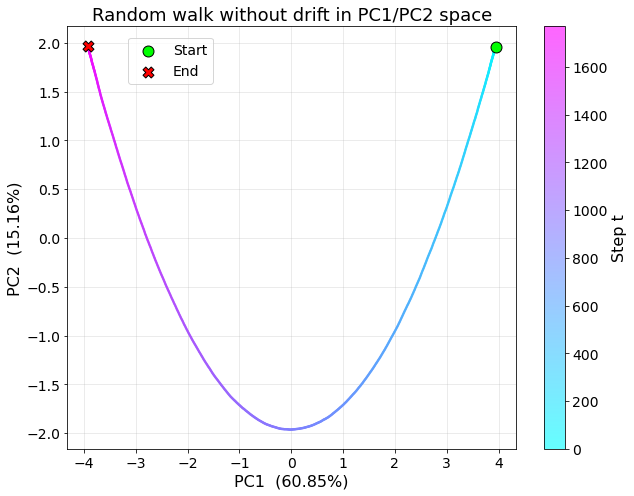

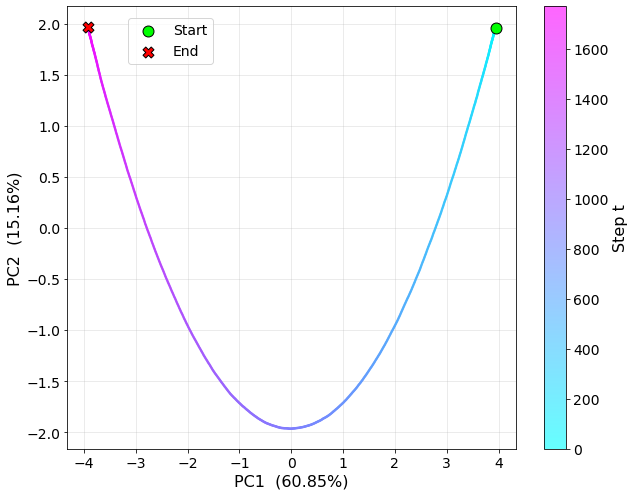

In [46]:
plot_rw_nodrift(show_title=True)
plot_rw_nodrift(show_title=False)

In [16]:
# ============================================================
#  ZELLE RW9 – Numerischer Vergleich
# ============================================================

print('=' * 65)
print(f'{"Metrik":<35} {"SGD":>8} {"RW (kein Drift)":>15} {"RW (Drift)":>10}')
print('=' * 65)

# PC1 erklärte Varianz
print(f'{"PC1 erklärte Varianz (%)":35} {explained[0]:>8.2f} {exp_nd[0]:>15.2f} {exp_wd[0]:>10.2f}')

# PC1+PC2
print(f'{"PC1+PC2 kumulativ (%)":35} {explained[:2].sum():>8.2f} {exp_nd[:2].sum():>15.2f} {exp_wd[:2].sum():>10.2f}')

# PCs für 90% Varianz
def pcs_for_threshold(exp, threshold=90):
    return np.argmax(np.cumsum(exp) >= threshold) + 1

print(f'{"PCs für 90% Varianz":35} {pcs_for_threshold(explained):>8} {pcs_for_threshold(exp_nd):>15} {pcs_for_threshold(exp_wd):>10}')

# Abweichung von RW-Theorie
theory_base = 6 / (np.pi**2 * np.arange(1, N_COMPONENTS_RW+1)**2)
theory_base = theory_base / theory_base.sum() * 100

delta_sgd = np.abs(explained/explained.sum()*100 - theory_base/theory_base.sum()*100).sum()
delta_nd  = np.abs(exp_nd/exp_nd.sum()*100     - theory_base/theory_base.sum()*100).sum()
delta_wd  = np.abs(exp_wd/exp_wd.sum()*100     - theory_base/theory_base.sum()*100).sum()

print(f'{"Abweichung von Theorie (Δ)":35} {delta_sgd:>8.2f} {delta_nd:>15.2f} {delta_wd:>10.2f}')

# Pfadlänge
pl_sgd = np.linalg.norm(np.diff(iterates,    axis=0), axis=1).sum()
pl_nd  = np.linalg.norm(np.diff(rw_no_drift, axis=0), axis=1).sum()
pl_wd  = np.linalg.norm(np.diff(rw_drift,    axis=0), axis=1).sum()
print(f'{"Pfadlänge (gesamt)":35} {pl_sgd:>8.1f} {pl_nd:>15.1f} {pl_wd:>10.1f}')

# Nettoverschiebung
net_sgd = np.linalg.norm(iterates[-1]    - iterates[0])
net_nd  = np.linalg.norm(rw_no_drift[-1] - rw_no_drift[0])
net_wd  = np.linalg.norm(rw_drift[-1]    - rw_drift[0])
print(f'{"Nettoverschiebung":35} {net_sgd:>8.1f} {net_nd:>15.1f} {net_wd:>10.1f}')

# Effizienz
print(f'{"Effizienz (Netto/Pfad)":35} {net_sgd/pl_sgd:>8.4f} {net_nd/pl_nd:>15.4f} {net_wd/pl_wd:>10.4f}')

print('=' * 65)

Metrik                                   SGD RW (kein Drift) RW (Drift)
PC1 erklärte Varianz (%)               75.46           60.85      99.86
PC1+PC2 kumulativ (%)                  87.16           76.01      99.92
PCs für 90% Varianz                        3               6          1
Abweichung von Theorie (Δ)             28.47            0.16      74.45
Pfadlänge (gesamt)                     367.3           367.3      367.3
Nettoverschiebung                       33.9             8.7      183.8
Effizienz (Netto/Pfad)                0.0923          0.0238     0.5005
